# Aim
To analyse the relationship between **Juvenile gender-wise crime rates** and **Total gender-wise crime rates**, to see if Juvenile crime rates can be a determining factor for adult crime rates.

# Fetching Data

In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [48]:
data=pd.read_csv("NCRB_CII-2019_Table_19B.2.csv")         # Fetching data

# Preliminary Analyses

## Data features

In [49]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 20 columns):
 #   Column                                           Non-Null Count  Dtype
---  ------                                           --------------  -----
 0   S. No                                            20 non-null     str  
 1   City                                             20 non-null     str  
 2    Juveniles Apprehended - Boys                    20 non-null     int64
 3    Juveniles Apprehended - Girls                   20 non-null     int64
 4    Juveniles Apprehended - Total                   20 non-null     int64
 5   18 and above and below 30 years - Male           20 non-null     int64
 6   18 and above and below 30 years - Female         20 non-null     int64
 7   18 and above and below 30 years - Total          20 non-null     int64
 8   30 and above and below 45 years - Male           20 non-null     int64
 9   30 and above and below 45 years - Female         20 non-null     in

In [50]:
data.columns

Index(['S. No', 'City', ' Juveniles Apprehended - Boys',
       ' Juveniles Apprehended - Girls', ' Juveniles Apprehended - Total',
       '18 and above and below 30 years - Male',
       '18 and above and below 30 years - Female',
       '18 and above and below 30 years - Total',
       '30 and above and below 45 years - Male',
       '30 and above and below 45 years - Female',
       '30 and above and below 45 years - Total',
       '45 and above and below 60 years - Male',
       '45 and above and below 60 years - Female',
       '45 and above and below 60 years - Total', '60 years and above - Male',
       '60 years and above - Female', '60 years and above - Total',
       'Total   - Male', 'Total   - Female',
       'Total   - Total Persons Arrested by age and Sex'],
      dtype='str')

Spacing and names of feature variables are non-uniform. 

In [51]:
data.columns = [
    'S_No', 'City',
    'Male_juveniles', 'Female_juveniles', 'Total_juveniles',
    'Male_18to30', 'Female_18to30', 'Total_18to30',
    'Male_30to45', 'Female_30to45', 'Total_30to45',
    'Male_45to60', 'Female_45to60', 'Total_45to60',
    'Male_60plus', 'Female_60plus', 'Total_60plus',
    'Male_total', 'Female_total', 'Grand_total'
]
print('Spacing and names of feature variables are now uniform.')

Spacing and names of feature variables are now uniform.


## Viewing the data

In [52]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   S_No              20 non-null     str  
 1   City              20 non-null     str  
 2   Male_juveniles    20 non-null     int64
 3   Female_juveniles  20 non-null     int64
 4   Total_juveniles   20 non-null     int64
 5   Male_18to30       20 non-null     int64
 6   Female_18to30     20 non-null     int64
 7   Total_18to30      20 non-null     int64
 8   Male_30to45       20 non-null     int64
 9   Female_30to45     20 non-null     int64
 10  Total_30to45      20 non-null     int64
 11  Male_45to60       20 non-null     int64
 12  Female_45to60     20 non-null     int64
 13  Total_45to60      20 non-null     int64
 14  Male_60plus       20 non-null     int64
 15  Female_60plus     20 non-null     int64
 16  Total_60plus      20 non-null     int64
 17  Male_total        20 non-null     int64
 18  Fem

In [53]:
data.describe()

,Male_juveniles,Female_juveniles,Total_juveniles,Male_18to30,Female_18to30,Total_18to30,Male_30to45,Female_30to45,Total_30to45,Male_45to60,Female_45to60,Total_45to60,Male_60plus,Female_60plus,Total_60plus,Male_total,Female_total,Grand_total
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,779.000000,1.600000,780.600000,20142.200000,843.200000,20985.400000,14236.500000,1045.100000,15281.600000,5403.80000,434.700000,5838.500000,523.500000,67.300000,590.800000,41085.000000,2391.900000,43476.900000
std,1782.633622,3.719083,1785.900787,44281.912065,1837.630872,46076.168831,31117.664553,2303.506729,33381.020656,12036.97896,953.371364,12974.710606,1194.608701,148.321166,1336.556006,89935.167676,5228.319614,95065.813305
min,0.000000,0.000000,0.000000,1192.000000,0.000000,1197.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,4087.000000,0.000000,4258.000000
25%,24.250000,0.000000,24.250000,4808.500000,51.500000,4936.250000,2797.750000,116.000000,2939.000000,817.50000,39.750000,886.750000,43.250000,0.750000,56.750000,8263.000000,252.000000,8281.000000
50%,286.500000,0.000000,289.500000,7201.500000,320.000000,8003.000000,4413.500000,383.000000,5042.500000,1429.00000,215.500000,1684.500000,156.000000,18.500000,173.000000,13589.500000,1085.000000,14850.500000
75%,486.750000,2.000000,488.750000,13612.000000,963.250000,14325.500000,10297.750000,890.000000,11350.750000,3028.75000,391.500000,3513.000000,438.250000,68.500000,519.500000,27727.250000,2156.000000,30006.500000
max,7790.000000,16.000000,7806.000000,201422.000000,8432.000000,209854.000000,142365.000000,10451.000000,152816.000000,54038.00000,4347.000000,58385.000000,5235.000000,673.000000,5908.000000,410850.000000,23919.000000,434769.000000


In [54]:
data

,S_No,City,Male_juveniles,Female_juveniles,Total_juveniles,Male_18to30,Female_18to30,Total_18to30,Male_30to45,Female_30to45,Total_30to45,Male_45to60,Female_45to60,Total_45to60,Male_60plus,Female_60plus,Total_60plus,Male_total,Female_total,Grand_total
0,1,Ahmedabad (Gujarat),298,0,298,14488,950,15438,12385,1290,13675,4264,668,4932,463,146,609,31898,3054,34952
1,2,Bengaluru(Karnataka),197,3,200,13577,579,14156,9602,974,10576,2531,381,2912,430,84,514,26337,2021,28358
2,3,Chennai(Tamil Nadu),816,0,816,13717,1117,14834,21194,2577,23771,16070,917,16987,2007,93,2100,53804,4704,58508
3,4,Coimbatore(Tamil Nadu),35,0,35,3248,488,3736,2674,293,2967,759,189,948,224,62,286,6940,1032,7972
4,5,Delhi,3073,2,3075,54129,1003,55132,30474,834,31308,8769,266,9035,514,22,536,96959,2127,99086
5,6,Ghaziabad(Uttar Pradesh),0,0,0,1192,5,1197,2241,1,2242,837,1,838,0,0,0,4270,7,4277
6,7,Hyderabad(Telangana),377,0,377,2839,150,2989,3376,129,3505,1197,30,1227,101,1,102,7890,310,8200
7,8,Indore(Madhya Pradesh),275,6,281,5396,248,5644,2873,198,3071,635,74,709,52,11,63,9231,537,9768
8,9,Jaipur(Rajasthan),404,1,405,7630,491,8121,4533,474,5007,2421,250,2671,121,19,140,15109,1235,16344
9,10,Kanpur(Uttar Pradesh),9,0,9,5360,52,5412,2228,17,2245,752,7,759,0,0,0,8349,76,8425


## Plots:

<Axes: xlabel='Male_juveniles', ylabel='Male_total'>

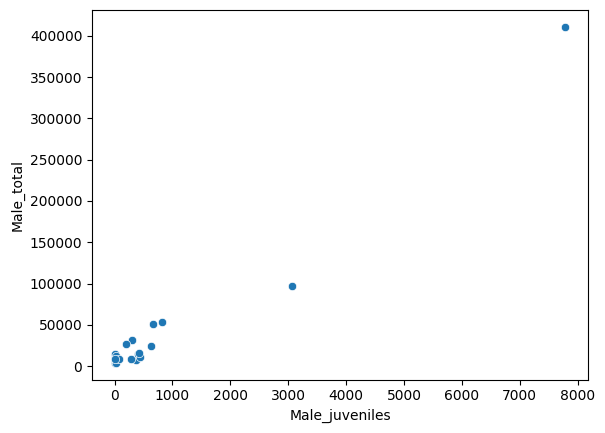

In [55]:
sns.scatterplot(x="Male_juveniles", y="Male_total", data=data)

<Axes: xlabel='Female_juveniles', ylabel='Female_total'>

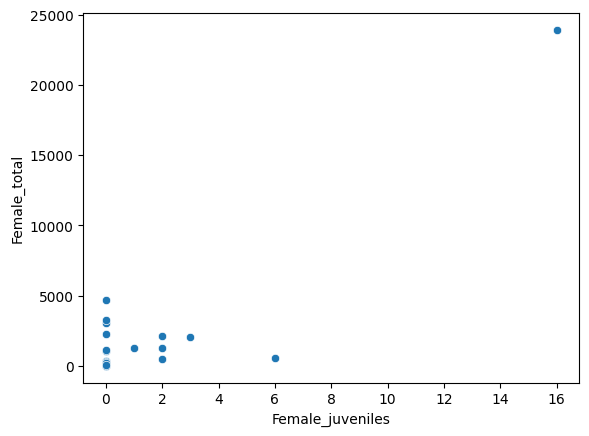

In [56]:
sns.scatterplot(x="Female_juveniles", y="Female_total", data=data)

<Axes: xlabel='Total_juveniles', ylabel='Grand_total'>

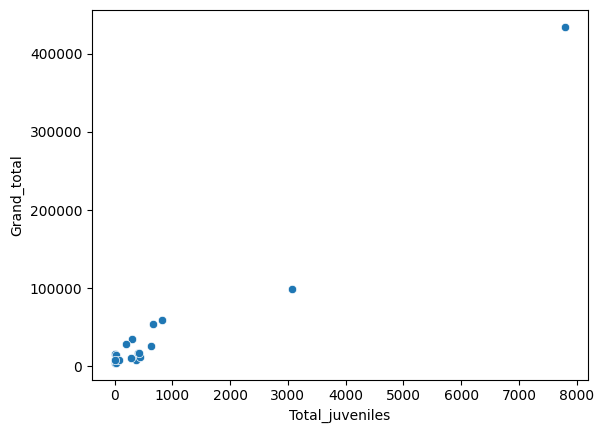

In [57]:
sns.scatterplot(x="Total_juveniles", y="Grand_total", data=data)

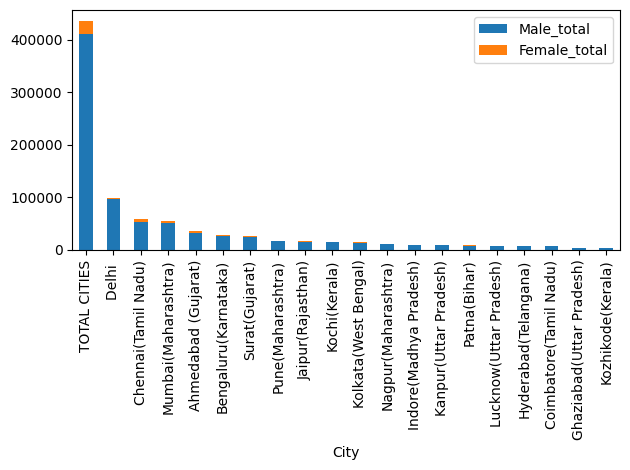

In [58]:
sorted_data = data.sort_values(by="Grand_total", ascending=False)

sorted_data.set_index("City")[["Male_total", "Female_total"]].plot(
    kind="bar",
    stacked=True
)

plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()

## Observations:

- Column names were updated to enforce uniformity.
- TOTAL CITIES appears to be an outlier
- Crime rates among females is much lower than among males
- Across each gender, crime rates among juveniles is lower than the total crime rates.

# Preprocessing

## Imputing

In [59]:
data.isna().sum()

S_No                0
City                0
Male_juveniles      0
Female_juveniles    0
Total_juveniles     0
Male_18to30         0
Female_18to30       0
Total_18to30        0
Male_30to45         0
Female_30to45       0
Total_30to45        0
Male_45to60         0
Female_45to60       0
Total_45to60        0
Male_60plus         0
Female_60plus       0
Total_60plus        0
Male_total          0
Female_total        0
Grand_total         0
dtype: int64

No empty/invalid values to impute

## Duplicate removal

In [60]:
n_duplicate_rows=data.duplicated().sum()
print(f'There are {n_duplicate_rows} duplicate rows.')
if n_duplicate_rows==0:
    print('No removal of duplicates required')
else:
    print('Must remove duplicates')

There are 0 duplicate rows.
No removal of duplicates required


## Dropping Grand Total row
Total cities entry has a different scale, which will lead to inaccuracies in analysis. Hence, we will remove it from the original dataset.

In [61]:
data_total_cities=data.iloc[-1]
data_total_cities

S_No                 Grand Total
City                TOTAL CITIES
Male_juveniles              7790
Female_juveniles              16
Total_juveniles             7806
Male_18to30               201422
Female_18to30               8432
Total_18to30              209854
Male_30to45               142365
Female_30to45              10451
Total_30to45              152816
Male_45to60                54038
Female_45to60               4347
Total_45to60               58385
Male_60plus                 5235
Female_60plus                673
Total_60plus                5908
Male_total                410850
Female_total               23919
Grand_total               434769
Name: 19, dtype: object

In [62]:
data.drop(data.index[-1], inplace=True)

<Axes: xlabel='Male_juveniles', ylabel='Male_total'>

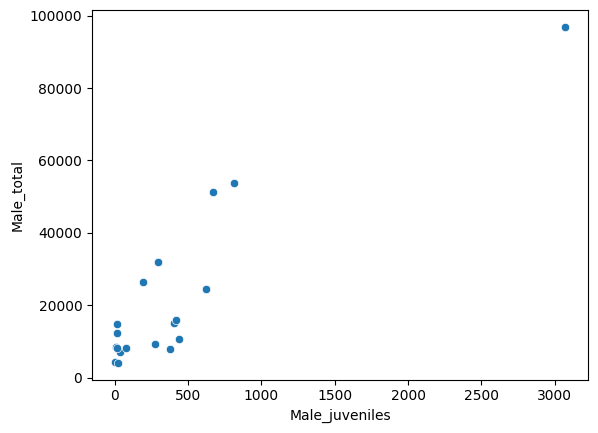

In [63]:
sns.scatterplot(x="Male_juveniles", y="Male_total", data=data)

Notice that one of the entries seems to be disproportionate. Let's check whether it is an error.

In [64]:
outlier = data[
    (data["Male_juveniles"] == data["Male_juveniles"].max()) &
    (data["Male_total"] == data["Male_total"].max())
]

outlier

,S_No,City,Male_juveniles,Female_juveniles,Total_juveniles,Male_18to30,Female_18to30,Total_18to30,Male_30to45,Female_30to45,Total_30to45,Male_45to60,Female_45to60,Total_45to60,Male_60plus,Female_60plus,Total_60plus,Male_total,Female_total,Grand_total
4,5,Delhi,3073,2,3075,54129,1003,55132,30474,834,31308,8769,266,9035,514,22,536,96959,2127,99086


Outlier does not seem to be an error. However, presence of such extreme outliers emphasises need to employ **scaling**.

<Axes: xlabel='Female_juveniles', ylabel='Female_total'>

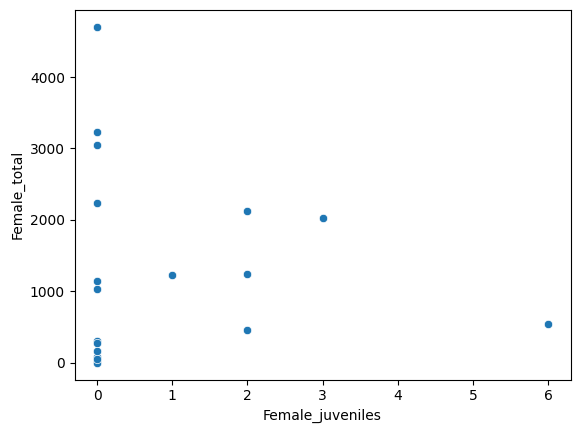

In [65]:
sns.scatterplot(x="Female_juveniles", y="Female_total", data=data)

<Axes: xlabel='Total_juveniles', ylabel='Grand_total'>

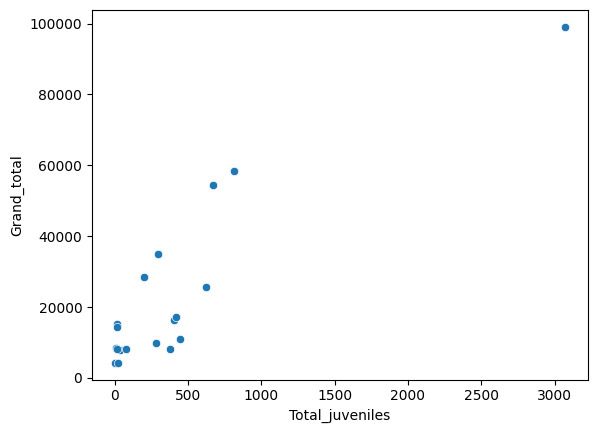

In [66]:
sns.scatterplot(x="Total_juveniles", y="Grand_total", data=data)

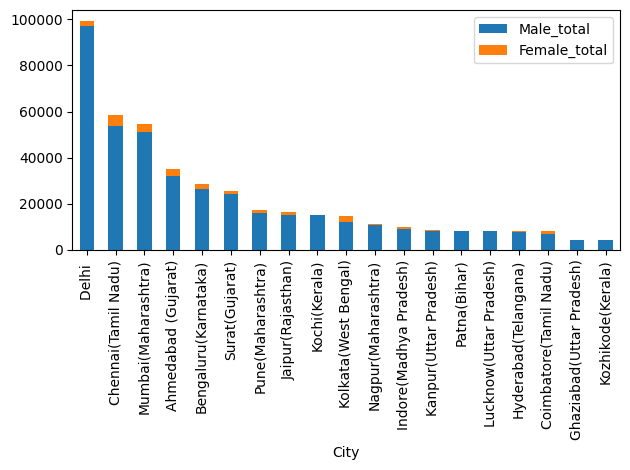

In [77]:
sorted_data = data.sort_values(by="Grand_total", ascending=False)
sorted_data.set_index("City")[["Male_total", "Female_total"]].plot(
    kind="bar",
    stacked=True
)
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()

Outlier (TOTAL CITIES) has been dropped

## Feature Selection
- Since we are trying to anaylse the effect of juvenile crime rates on total crime rates, we ignore the index variables 'Cities' and 'S.no'
- We will plot the correlation between the different training variables to filter out redundancy

<Axes: xlabel='Female_juveniles', ylabel='Total_juveniles'>

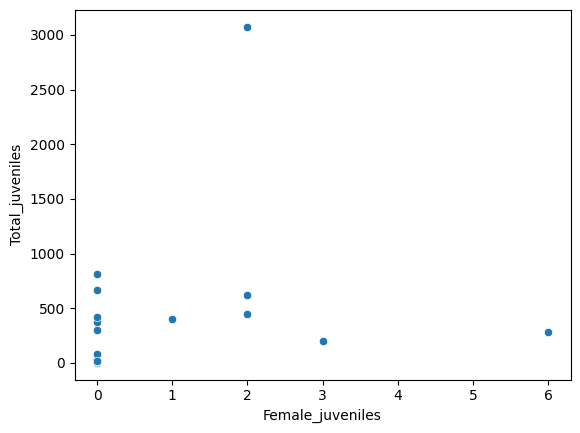

In [68]:
sns.scatterplot(x='Female_juveniles', y='Total_juveniles', data=data)

<Axes: xlabel='Male_juveniles', ylabel='Total_juveniles'>

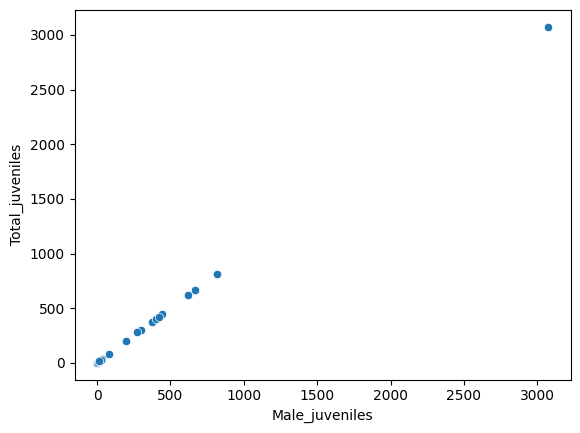

In [69]:
sns.scatterplot(x='Male_juveniles', y='Total_juveniles', data=data)

<Axes: xlabel='Male_juveniles', ylabel='Female_juveniles'>

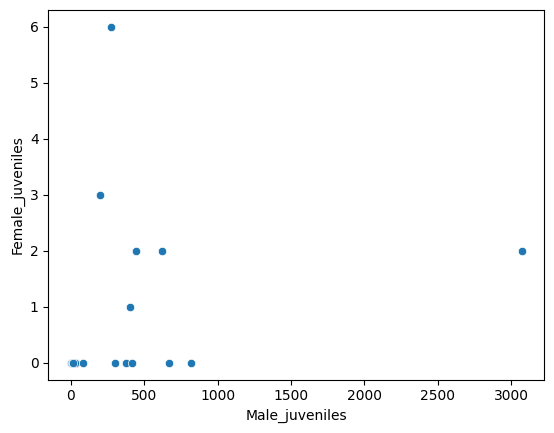

In [70]:
sns.scatterplot(x='Male_juveniles', y='Female_juveniles', data=data)

In [71]:
data.loc[:,['Male_juveniles', 'Female_juveniles', 'Total_juveniles','Male_total', 'Female_total', 'Grand_total']].corr(numeric_only=True)

,Male_juveniles,Female_juveniles,Total_juveniles,Male_total,Female_total,Grand_total
Male_juveniles,1.000000,0.222180,0.999998,0.903306,0.384049,0.889881
Female_juveniles,0.222180,1.000000,0.224337,0.102306,-0.052183,0.095551
Total_juveniles,0.999998,0.224337,1.000000,0.903080,0.383736,0.889647
Male_total,0.903306,0.102306,0.903080,1.000000,0.682171,0.999199
Female_total,0.384049,-0.052183,0.383736,0.682171,1.000000,0.710876
Grand_total,0.889881,0.095551,0.889647,0.999199,0.710876,1.000000


There is nearly correlation of 1 between Male_juveniles and Total_juveniles. This is redundant. We shall drop Total_juveniles

In [72]:
X_cols=['Male_juveniles', 'Female_juveniles']
y_cols=['Male_total', 'Female_total', 'Grand_total']
X=data.loc[:,X_cols].to_numpy()
y=data.loc[:,y_cols].to_numpy()
print(f'Shape of X:{X.shape}\nShape of y:{y.shape}')

Shape of X:(19, 2)
Shape of y:(19, 3)


## Scaling
We note that each column has a different scale. Specifically, the female crime rates are an order of magnitude below that of the male crime rates. Hence we now apply scaling.

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [75]:
min_max_scaler=MinMaxScaler()
X_minmax_train=min_max_scaler.fit_transform(X_train)
X_minmax_test=min_max_scaler.transform(X_test)

In [76]:
std_scaler=StandardScaler()
X_std_train=std_scaler.fit_transform(X_train)
X_std_test=std_scaler.transform(X_test)

## Observations

- There is a visible correlation between Male_juveniles and Male_total, and between Total_juveniles and Grand_total.
- There is no visible correlation between Female_juveniles and Female_total.
- There is high correlation between Male_juveniles and Total_juveniles. To avoid redundancy, Total_juveniles has been dropped.
- 2 scalers have been fit onto training data, and it has been used to transform test and training data.